<h2> Raphaela Maria Costa e Silva - 2020006973

<h2>Introdução

A otimização dos hiperparâmetros é uma etapa crucial no treinamento de redes neurais, influenciando diretamente o desempenho e a eficiência do modelo final. Neste estudo, exploramos a variação de três hiperparâmetros principais: o número de unidades na camada oculta, o algoritmo de cálculo do gradiente e a taxa de aprendizado. Analisamos como esses fatores impactam a convergência do modelo, observando tanto a estabilidade quanto a eficácia na redução dos erros de treinamento e validação.



<h2> Import bibliotecas e módulos </h2>

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import itertools
import pandas as pd
from keras.utils import to_categorical

# CNN
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten

# plot
from matplotlib import pyplot as plt
%matplotlib inline

np.random.seed(123)  # for reproducibility

<h2> Download dos Dados</h2>

In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1ki-AN7cVg1ONQBWtzWi6n2TWAnM99udv' -O 'dados.csv'


--2024-06-17 00:35:49--  https://docs.google.com/uc?export=download&id=1ki-AN7cVg1ONQBWtzWi6n2TWAnM99udv
Resolving docs.google.com (docs.google.com)... 74.125.69.101, 74.125.69.100, 74.125.69.139, ...
Connecting to docs.google.com (docs.google.com)|74.125.69.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ki-AN7cVg1ONQBWtzWi6n2TWAnM99udv&export=download [following]
--2024-06-17 00:35:49--  https://drive.usercontent.google.com/download?id=1ki-AN7cVg1ONQBWtzWi6n2TWAnM99udv&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.195.132, 2607:f8b0:4001:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.195.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9061376 (8.6M) [application/octet-stream]
Saving to: ‘dados.csv’

dados.csv           100%[===================>]   8.64M  --.-KB/s    in 0.08s

<h2> Leitura e pre-processamento dos dados</h2>

In [ ]:
df = pd.read_csv('dados.csv', header=None)
print(df.shape)

(5000, 785)


In [ ]:
df = df.to_numpy()
x = df[:,1:]
y = df[:,0]

In [ ]:
print(x.shape)
print(y.shape)

(5000, 784)
(5000,)


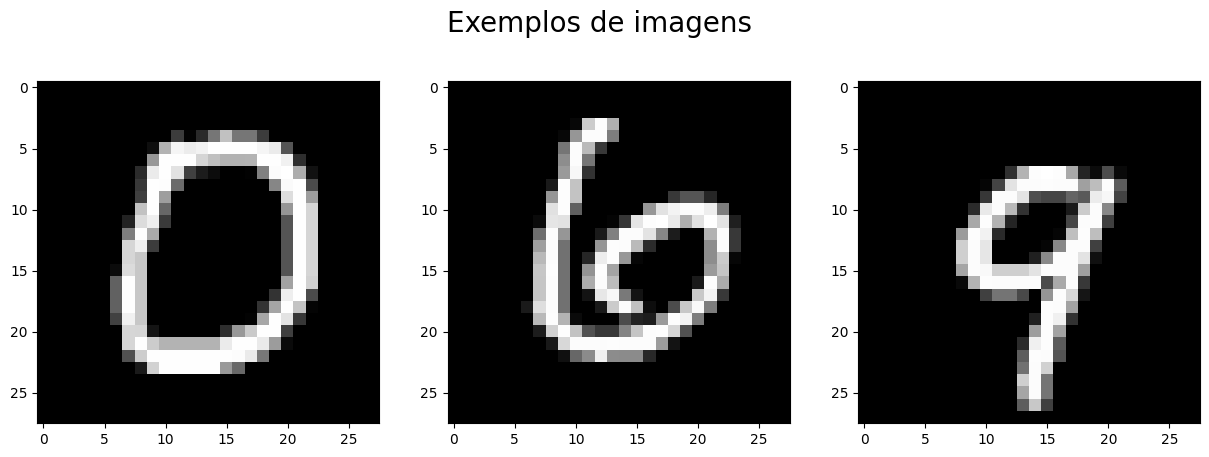

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Exemplos de imagens', fontsize=20)

axes[0].imshow(x[10].reshape(28,28), cmap="gray")
axes[1].imshow(x[11].reshape(28,28), cmap="gray")
axes[2].imshow(x[12].reshape(28,28), cmap="gray")


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=123)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(4000, 784)
(1000, 784)
(4000,)
(1000,)


In [ ]:
# normalize our data values to the range [0, 1]
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_test =  X_test.astype('float32')

X_train /= 255
X_test /= 255
X_test /= 255

#to categorical
Y_train = to_categorical(Y_train, dtype = "uint8")
Y_test = to_categorical(Y_test, dtype = "uint8")


<h2>Define modelos da arquitetura</h2>

O código abaixo define três funções principais para construir, treinar e avaliar um modelo de rede neural. A função build_model cria um modelo sequencial com uma camada oculta e uma camada de saída, especificando funções de ativação e forma de entrada. A função get_optimizer retorna um otimizador configurado com base no nome e na taxa de aprendizado fornecidos. A função get_errors_and_score treina o modelo usando dados de treinamento, aplica early stopping para evitar overfitting, avalia o modelo com dados de teste e retorna o histórico de treinamento, a pontuação de avaliação e os parâmetros usados.








In [ ]:
def build_model(input_shape, hidden_layer=50, output_units=10, activation_hidden='sigmoid', activation_output='softmax'):
    model = models.Sequential([
        layers.Dense(hidden_layer, activation=activation_hidden, input_shape=input_shape),
        layers.Dense(output_units, activation=activation_output)
    ])
    return model

def get_optimizer(optimizer_name='SGD', learning_rate=0.001):
    optimizers_dict = {
        'SGD': optimizers.SGD(learning_rate=learning_rate),
        'Adam': optimizers.Adam(learning_rate=learning_rate),
        'RMSprop': optimizers.RMSprop(learning_rate=learning_rate)
    }
    return optimizers_dict.get(optimizer_name, optimizers.SGD(learning_rate=learning_rate))

def get_errors_and_score(x_train, y_train, x_test, y_test, hidden_layer=50, learning_rate=0.001, batch_size=15, optimizer_name='SGD', activation_hidden='sigmoid'):
    input_shape = (x_train.shape[1],)
    model = build_model(input_shape, hidden_layer, activation_hidden=activation_hidden)
    optimizer = get_optimizer(optimizer_name, learning_rate)

    model.compile(loss='categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        callbacks=[early_stopping],
        verbose=2
    )

    score = model.evaluate(x_test, y_test, verbose=1)

    params = {
        'hidden_layer': hidden_layer,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': optimizer_name,
        'activation_hidden': activation_hidden
    }
    return history.history, score, params



A celula abaixo define uma função que realiza uma busca em grade (grid search) para encontrar a melhor combinação de hiperparâmetros para um modelo de rede neural, treinando e avaliando o modelo para cada combinação possível.



In [ ]:
# Exemplo de uso
def grid_search(x_train, y_train, x_test, y_test):
    len_train = x_train.shape[0]

    hidden_layers = [25, 50, 100]
    learning_rates = [0.5, 1, 10]
    batch_sizes = [1, 10, 50, len_train]

    metrics = []

    for h, lr, b in itertools.product(hidden_layers, learning_rates, batch_sizes):
        print(f"Treinando com hidden_layer={h}, learning_rate={lr}, batch_size={b}")
        metrics.append(get_errors_and_score(x_train, y_train, x_test, y_test, hidden_layer=h, learning_rate=lr, batch_size=b))

    return metrics

In [ ]:
tf.test.gpu_device_name()
metrics = grid_search(X_train, Y_train, X_test, Y_test)



Treinando com hidden_layer=25, learning_rate=0.5, batch_size=1
Epoch 1/20
4000/4000 - 8s - loss: 1.0704 - accuracy: 0.6595 - val_loss: 4.9751 - val_accuracy: 0.0850 - 8s/epoch - 2ms/step
Epoch 2/20
4000/4000 - 12s - loss: 0.7603 - accuracy: 0.7735 - val_loss: 6.4400 - val_accuracy: 0.0850 - 12s/epoch - 3ms/step
Epoch 3/20
4000/4000 - 11s - loss: 0.6869 - accuracy: 0.7983 - val_loss: 4.1897 - val_accuracy: 0.1000 - 11s/epoch - 3ms/step
Epoch 4/20
4000/4000 - 10s - loss: 0.6113 - accuracy: 0.8242 - val_loss: 6.7573 - val_accuracy: 0.0850 - 10s/epoch - 2ms/step
Epoch 5/20
4000/4000 - 8s - loss: 0.5462 - accuracy: 0.8418 - val_loss: 6.2328 - val_accuracy: 0.0850 - 8s/epoch - 2ms/step
Epoch 6/20
4000/4000 - 7s - loss: 0.5372 - accuracy: 0.8385 - val_loss: 6.8325 - val_accuracy: 0.0850 - 7s/epoch - 2ms/step
Epoch 7/20
4000/4000 - 8s - loss: 0.4351 - accuracy: 0.8773 - val_loss: 4.3870 - val_accuracy: 0.1450 - 8s/epoch - 2ms/step
Epoch 8/20
4000/4000 - 6s - loss: 0.4779 - accuracy: 0.8560 - v

In [ ]:
print(len(metrics))
print(metrics[:2])

36
[({'loss': [1.0704234838485718, 0.7602540254592896, 0.6868650913238525, 0.6113491058349609, 0.5462058782577515, 0.537176251411438, 0.435134619474411, 0.4779086112976074], 'accuracy': [0.659500002861023, 0.7735000252723694, 0.7982500195503235, 0.8242499828338623, 0.8417500257492065, 0.8385000228881836, 0.8772500157356262, 0.8560000061988831], 'val_loss': [4.97511625289917, 6.439966201782227, 4.189748764038086, 6.757315635681152, 6.232844829559326, 6.832535266876221, 4.386981010437012, 6.093180179595947], 'val_accuracy': [0.08500000089406967, 0.08500000089406967, 0.10000000149011612, 0.08500000089406967, 0.08500000089406967, 0.08500000089406967, 0.14499999582767487, 0.17000000178813934]}, [4.189750671386719, 0.10000000149011612], {'hidden_layer': 25, 'learning_rate': 0.5, 'batch_size': 1, 'optimizer': 'SGD', 'activation_hidden': 'sigmoid'}), ({'loss': [0.7708780169487, 0.36013171076774597, 0.2702297270298004, 0.21371282637119293, 0.1744319647550583, 0.1413193941116333], 'accuracy': [0

<h2> Resultados

<h3> Batch Size


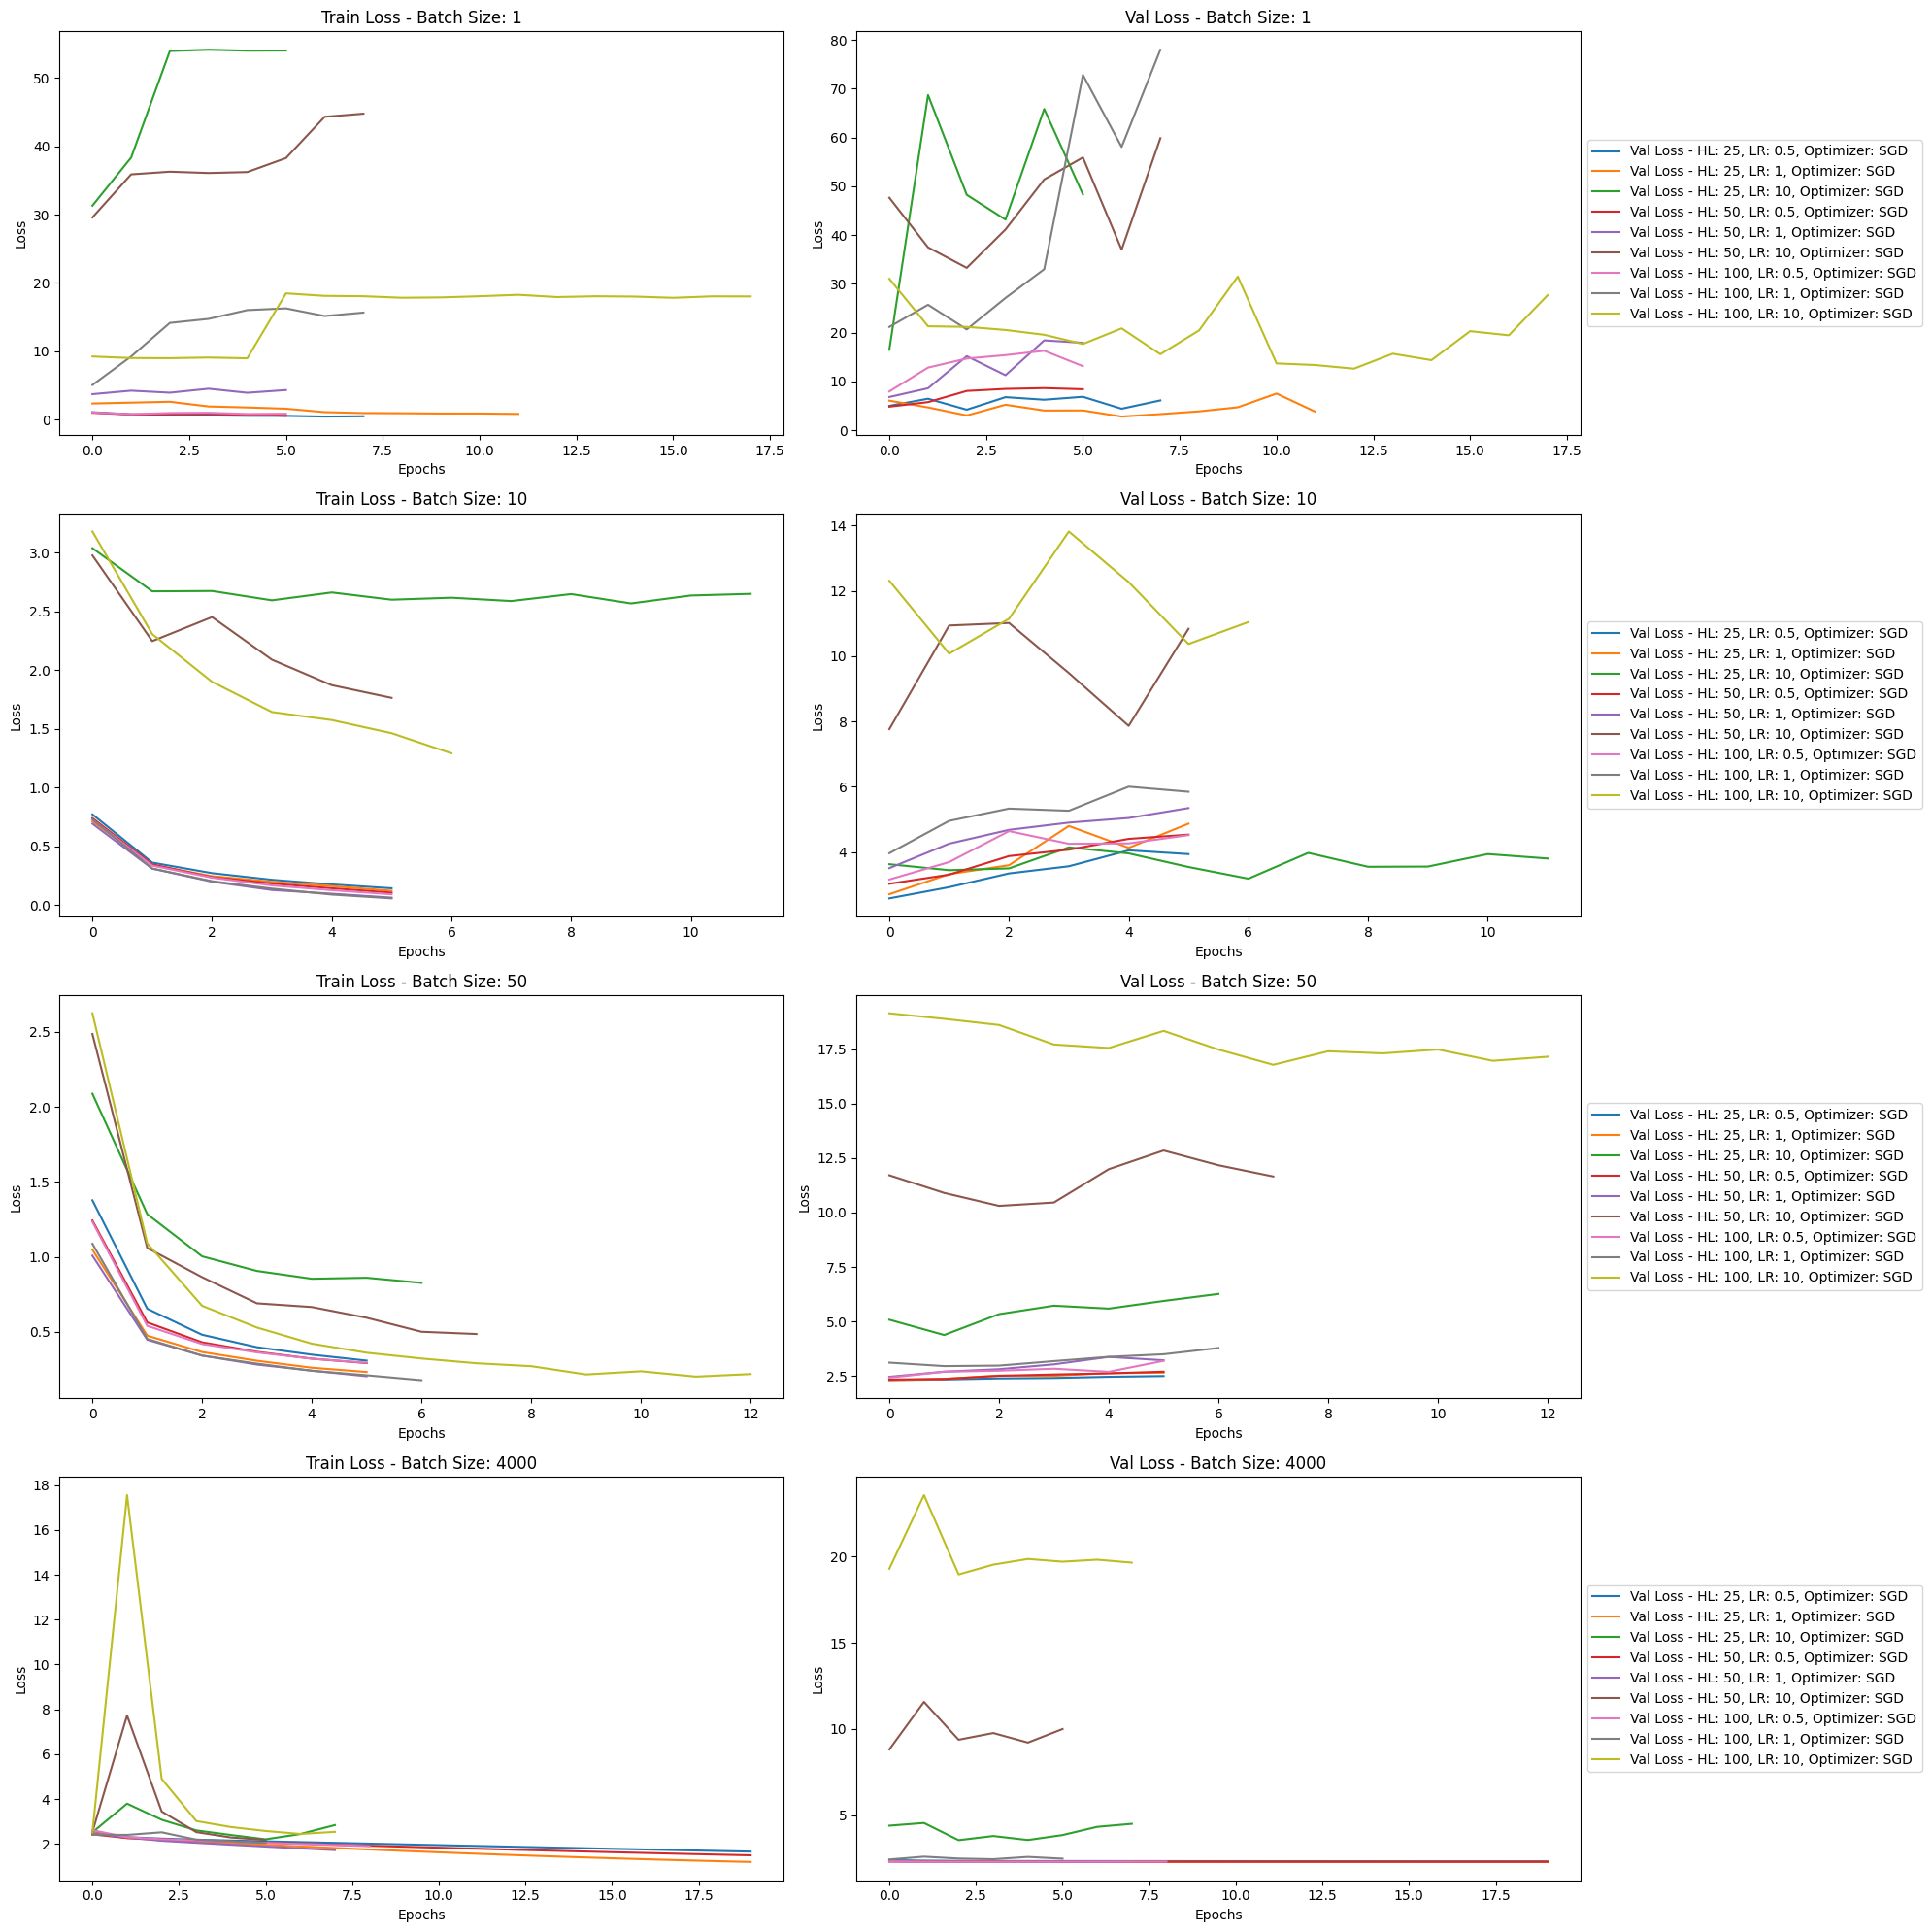

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(metrics):
    # Agrupar métricas por batch_size
    metrics_by_batch_size = {}
    for metric in metrics:
        history, _, params = metric
        batch_size = params['batch_size']
        if batch_size not in metrics_by_batch_size:
            metrics_by_batch_size[batch_size] = []
        metrics_by_batch_size[batch_size].append((history, params))

    # Preparar plots
    num_batch_sizes = len(metrics_by_batch_size)
    fig, axs = plt.subplots(num_batch_sizes, 2, figsize=(20, 5 * num_batch_sizes))

    # Iterar sobre os diferentes batch_size
    for i, (batch_size, metrics) in enumerate(metrics_by_batch_size.items()):
        for history, params in metrics:
            # Extrair métricas relevantes
            train_loss = history['loss']
            val_loss = history['val_loss']
            train_accuracy = history['accuracy']
            val_accuracy = history['val_accuracy']

            # Extrair parâmetros
            hidden_layer = params['hidden_layer']
            learning_rate = params['learning_rate']
            optimizer = params['optimizer']

            # Plotar gráfico de perda
            axs[i, 0].plot(train_loss, label=f'Train Loss - HL: {hidden_layer}, LR: {learning_rate}, Optimizer: {optimizer}')
            axs[i, 0].set_title(f'Train Loss - Batch Size: {batch_size}')
            axs[i, 0].set_xlabel('Epochs')
            axs[i, 0].set_ylabel('Loss')

            axs[i, 1].plot(val_loss, label=f'Val Loss - HL: {hidden_layer}, LR: {learning_rate}, Optimizer: {optimizer}')
            axs[i, 1].set_title(f'Val Loss - Batch Size: {batch_size}')
            axs[i, 1].set_xlabel('Epochs')
            axs[i, 1].set_ylabel('Loss')

        # Colocar a legenda fora do gráfico
        axs[i, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Exemplo de uso
plot_convergence(metrics)


Observamos que batch sizes menores levam a erros empíricos e de validação mais instáveis ao longo das épocas, com curvas de erro que variam significativamente. Em contraste, batch sizes maiores resultam em curvas de erro mais suaves e menos oscilações.
Comparando os algoritmos de cálculo do gradiente, notamos que o Gradient Descent (GD) tende a ter uma variação de erro menor do que o Stochastic Gradient Descent (SGD), enquanto o mini-batch GD se apresenta como um bom meio-termo entre essas opções. Isso pode ser explicado pela qualidade do gradiente calculado: quanto mais amostras são usadas no cálculo, mais precisa é a direção do gradiente, levando a atualizações de peso mais eficazes em direção ao mínimo local.

<h3> Camadas Ocultas

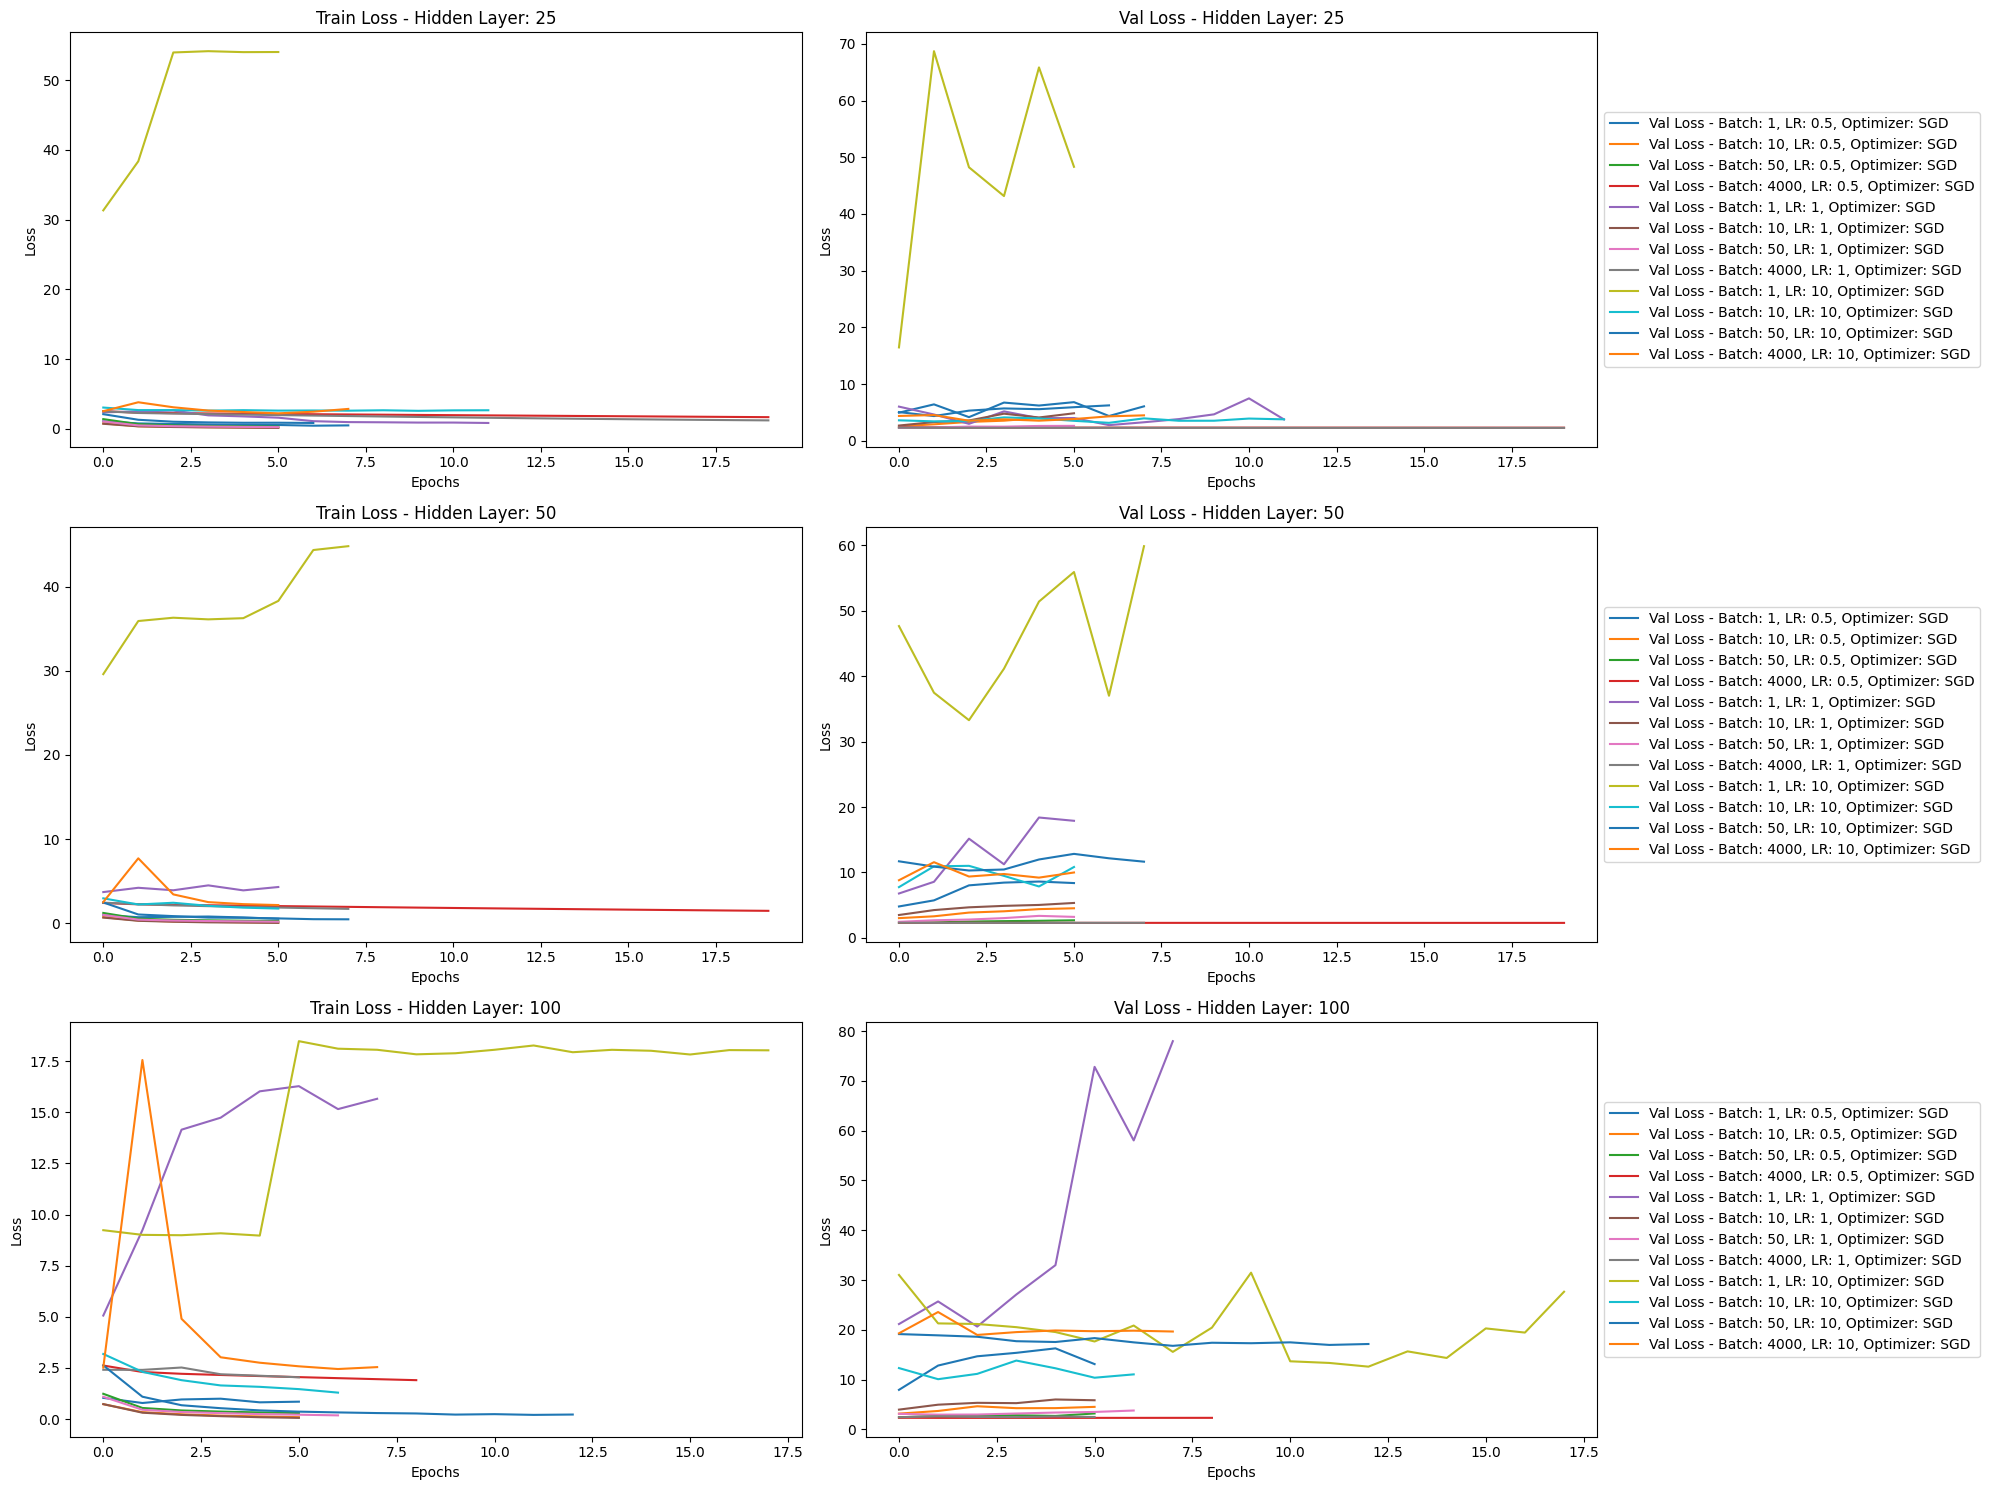

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(metrics):
    # Agrupar métricas por hidden_layer
    metrics_by_hidden_layer = {}
    for metric in metrics:
        history, _, params = metric
        hidden_layer = params['hidden_layer']
        if hidden_layer not in metrics_by_hidden_layer:
            metrics_by_hidden_layer[hidden_layer] = []
        metrics_by_hidden_layer[hidden_layer].append((history, params))

    # Preparar plots
    num_hidden_layers = len(metrics_by_hidden_layer)
    fig, axs = plt.subplots(num_hidden_layers, 2, figsize=(20, 5 * num_hidden_layers))

    # Iterar sobre os diferentes hidden_layers
    for i, (hidden_layer, metrics) in enumerate(metrics_by_hidden_layer.items()):
        for history, params in metrics:
            # Extrair métricas relevantes
            train_loss = history['loss']
            val_loss = history['val_loss']
            train_accuracy = history['accuracy']
            val_accuracy = history['val_accuracy']

            # Extrair parâmetros
            learning_rate = params['learning_rate']
            batch_size = params['batch_size']
            optimizer = params['optimizer']

            # Plotar gráfico de perda
            axs[i, 0].plot(train_loss, label=f'Train Loss - Batch: {batch_size}, LR: {learning_rate}, Optimizer: {optimizer}')
            axs[i, 0].set_title(f'Train Loss - Hidden Layer: {hidden_layer}')
            axs[i, 0].set_xlabel('Epochs')
            axs[i, 0].set_ylabel('Loss')

            axs[i, 1].plot(val_loss, label=f'Val Loss - Batch: {batch_size}, LR: {learning_rate}, Optimizer: {optimizer}')
            axs[i, 1].set_title(f'Val Loss - Hidden Layer: {hidden_layer}')
            axs[i, 1].set_xlabel('Epochs')
            axs[i, 1].set_ylabel('Loss')

        # Colocar a legenda fora do gráfico
        axs[i, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Exemplo de uso
plot_convergence(metrics)


Para o tamanho da camada oculta, não observamos mudanças significativas nos erros ao aumentar além de 25 unidades. Isso sugere que uma camada oculta com 25 unidades é capaz de capturar adequadamente a complexidade dos dados para a tarefa de classificação na camada de saída, tornando redundante um aumento adicional na quantidade de neurônios.

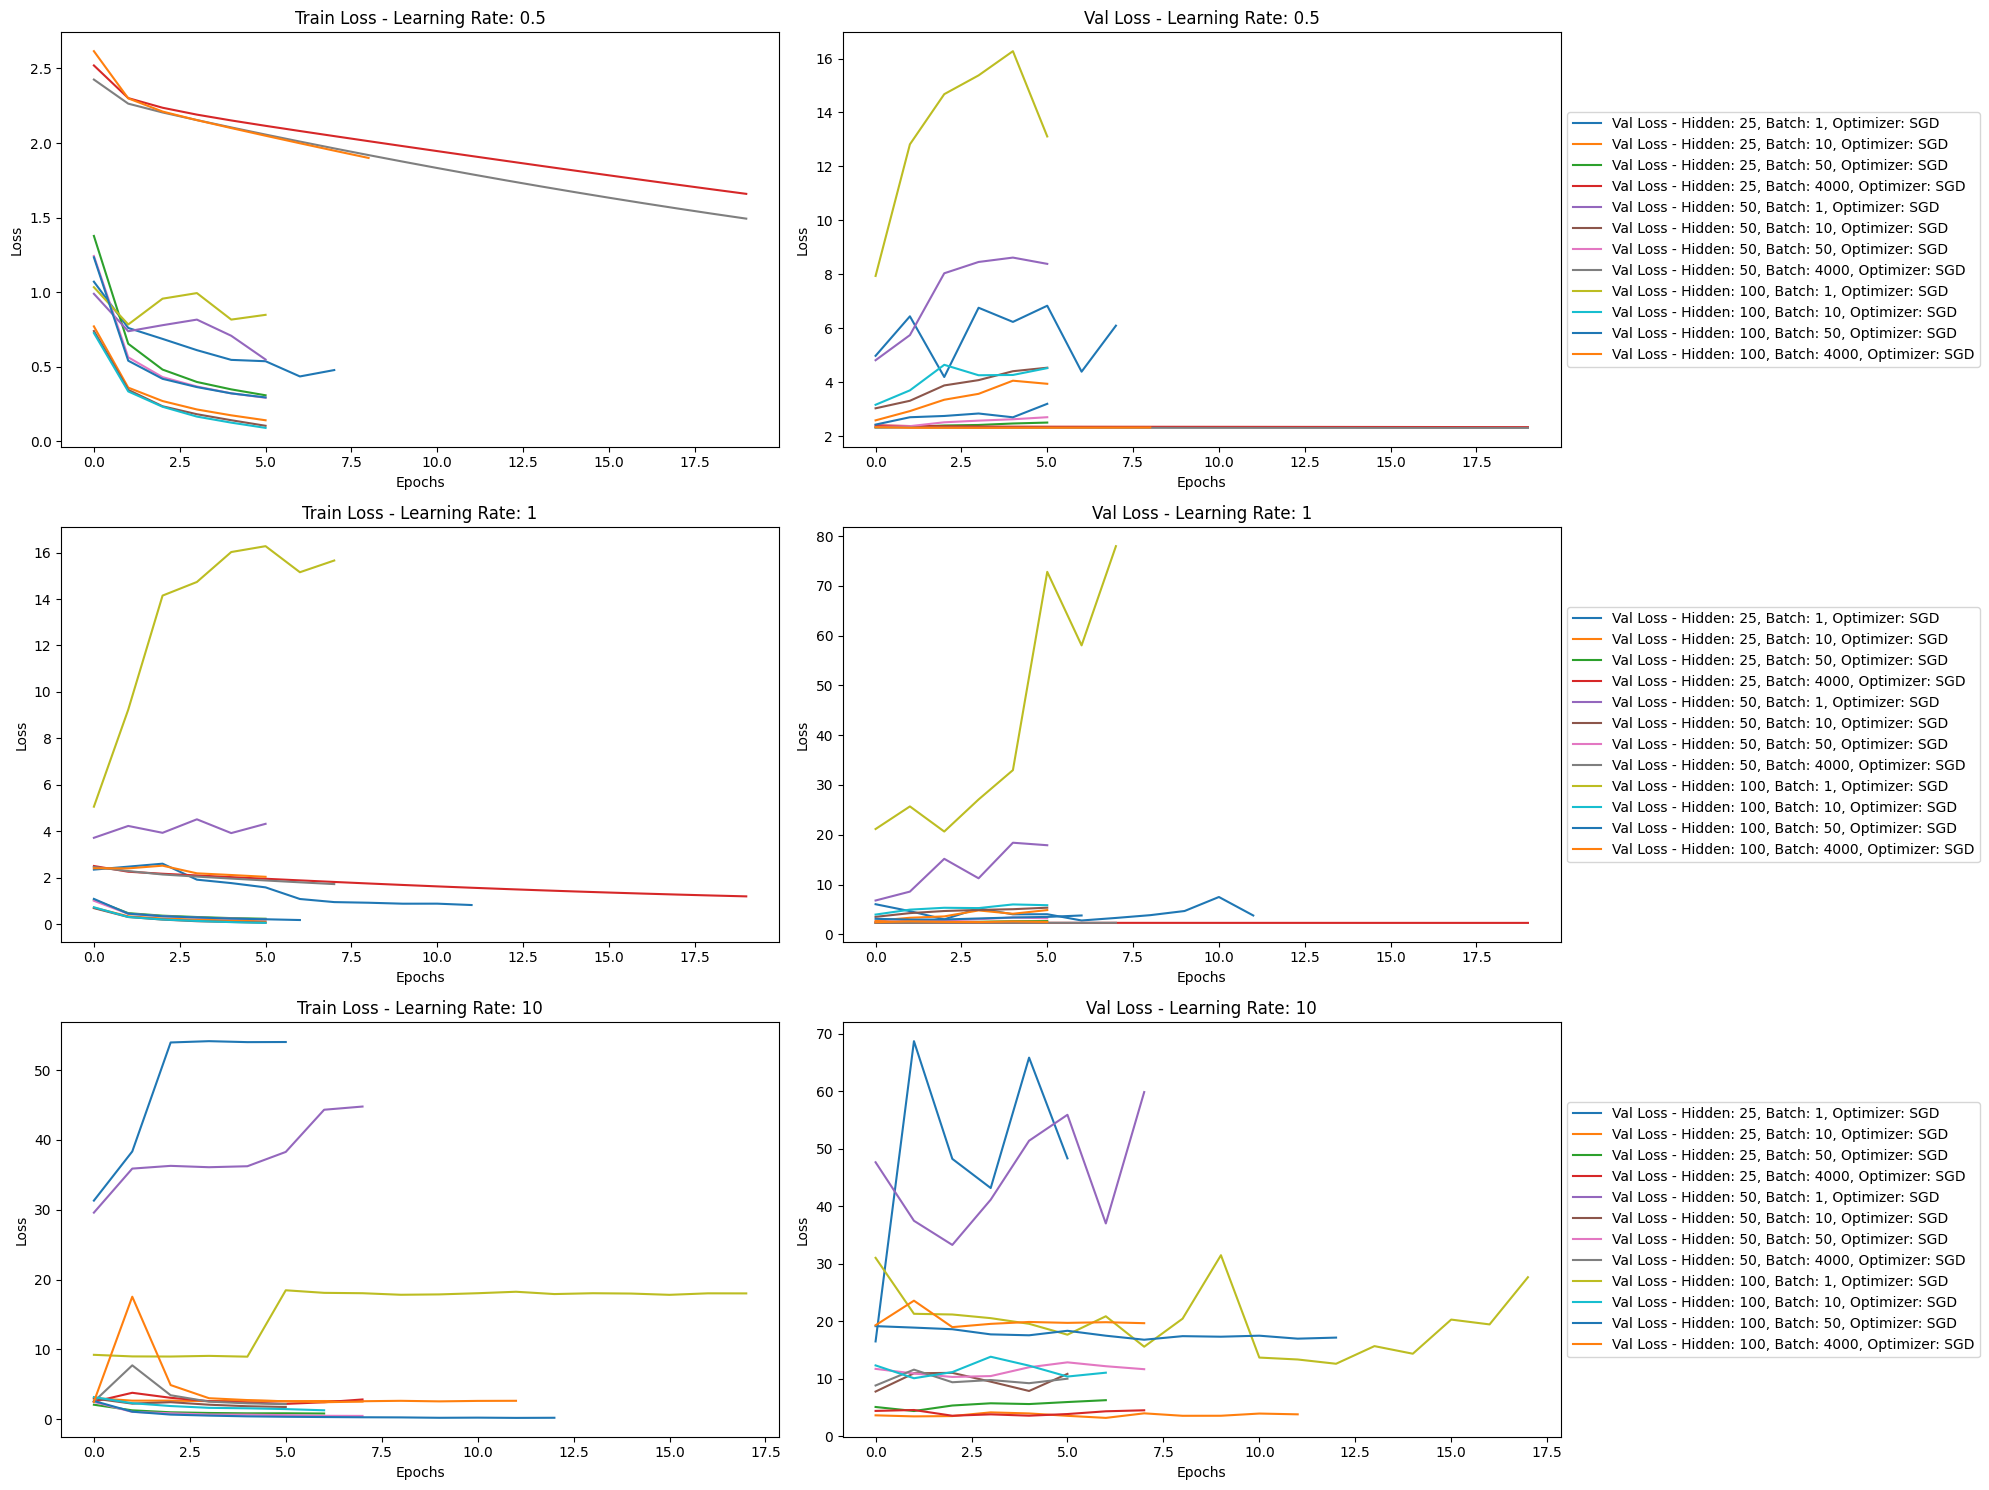

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(metrics):
    # Agrupar métricas por learning rate
    metrics_by_learning_rate = {}
    for metric in metrics:
        history, _, params = metric
        learning_rate = params['learning_rate']
        if learning_rate not in metrics_by_learning_rate:
            metrics_by_learning_rate[learning_rate] = []
        metrics_by_learning_rate[learning_rate].append((history, params))

    # Preparar plots
    num_learning_rates = len(metrics_by_learning_rate)
    fig, axs = plt.subplots(num_learning_rates, 2, figsize=(20, 5 * num_learning_rates))

    # Verificar se axs é um array bidimensional
    if num_learning_rates == 1:
        axs = np.expand_dims(axs, axis=0)

    # Iterar sobre as diferentes taxas de aprendizado
    for i, (learning_rate, metrics) in enumerate(metrics_by_learning_rate.items()):
        for history, params in metrics:
            # Extrair métricas relevantes
            train_loss = history['loss']
            val_loss = history['val_loss']
            train_accuracy = history['accuracy']
            val_accuracy = history['val_accuracy']

            # Extrair parâmetros
            hidden_layer = params['hidden_layer']
            batch_size = params['batch_size']
            optimizer = params['optimizer']

            # Plotar gráfico de perda
            axs[i, 0].plot(train_loss, label=f'Train Loss - Hidden: {hidden_layer}, Batch: {batch_size}, Optimizer: {optimizer}')
            axs[i, 0].set_title(f'Train Loss - Learning Rate: {learning_rate}')
            axs[i, 0].set_xlabel('Epochs')
            axs[i, 0].set_ylabel('Loss')

            axs[i, 1].plot(val_loss, label=f'Val Loss - Hidden: {hidden_layer}, Batch: {batch_size}, Optimizer: {optimizer}')
            axs[i, 1].set_title(f'Val Loss - Learning Rate: {learning_rate}')
            axs[i, 1].set_xlabel('Epochs')
            axs[i, 1].set_ylabel('Loss')

        # Colocar a legenda fora do gráfico
        axs[i, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Exemplo de uso
plot_convergence(metrics)


<h2> Taxa de aprendizado

Ao analisar a taxa de aprendizado, notamos que modelos usando SGD geralmente performam melhor com uma learning rate de 0.5, enquanto modelos utilizando mini-batch GD se saem melhor com uma learning rate de 1. Isso está relacionado à velocidade e precisão das atualizações de peso em direção ao mínimo local indicado pelo gradiente.
Uma taxa de aprendizado muito alta, como 10, resultou em modelos com baixa acurácia e erros instáveis. O pior desempenho foi observado ao usar learning rate 10 com SGD, onde os modelos tenderam a se comportar como classificadores aleatórios.


<h2> Conclusão

A escolha dos hiperparâmetros exerce um papel crucial na eficiência e na estabilidade do treinamento de redes neurais. Neste estudo, observamos que o batch size, a taxa de aprendizado e o tamanho da camada oculta têm impactos distintos no desempenho do modelo. Batch sizes menores tendem a tornar o treinamento mais instável, enquanto tamanhos maiores oferecem uma convergência mais suave, porém com maior custo computacional. Além disso, a taxa de aprendizado influencia diretamente na velocidade e na precisão do ajuste dos pesos da rede, sendo fundamental escolher um valor adequado para cada algoritmo de cálculo de gradiente utilizado. A camada oculta, por sua vez, deve ser dimensionada de acordo com a complexidade dos dados e a capacidade de generalização desejada.

Em resumo, o ajuste correto dos hiperparâmetros pode resultar em melhorias significativas no desempenho do modelo, enquanto escolhas inadequadas podem levar a resultados subótimos e até mesmo a uma falha no treinamento. Portanto, a seleção dos hiperparâmetros deve ser feita com cuidado, considerando as características específicas do problema e as propriedades do conjunto de dados.